In [29]:
require(IRdisplay)

Loading required package: IRdisplay



## Introduction

You may be familiar with linear regression, which models a linear relationship between `Y` and `X`. However, this assumption of linearity is sometimes violated. **What to do then?** The answer is to use a _Generalised Linear Model (GLM)_.

### Advantages of using GLMs

1. **Flexibility** in the types of response variable: while linear regression allows only a **continuous** response, GLMs handle many types.  
2. **Interpretability**: GLMs are still easy to interpret.

### When to use them?

1. When the assumption of **linearity** is violated.  
2. When the **response** variable is non-normal.

GLMs extend the linear model as follows:

$$
g(\mu_i) = \beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + \dots + \beta_p X_{ip}
$$

- \(g(\mu_i)\) is the **link function** that connects the expected value of the response to the linear predictor.

The only difference between linear regression and a GLM is the addition of this link function.

Different link functions are used for different types of response. Let’s explore some:

## Exponential Family

### Types of exponential-family distributions

- _Normal_
- _Poisson_
- _Exponential_

#### Moments

For an exponential-family distribution, moments are defined by

$$
m^{\text{th}}\text{ moment} = \operatorname{E}\!\bigl[(X - \operatorname{E}[X])^{m}\bigr]
$$

The first moment is the mean, the second is the variance, and so on.

Distributions **not** in the exponential family include

- Student-_t_
- Uniform

A distribution is in the exponential family if its PDF/PMF can be written as

$$
f(z \mid \xi) = \exp\!\bigl[t(z)\,u(\xi)\bigr]\; r(z)\,s(\xi)
$$

- \(z\): value of the random variable  
- \(\xi\): parameter  
- \(t(z), u(\xi), r(z), s(\xi)\): real-valued functions with \(r(z)>0,\; s(\xi)>0\)

For a random sample, the joint density is

$$
f(\mathbf z \mid \xi)=\exp\!\left[
  u(\xi)\sum_{i=1}^n t(z_i)+\sum_{i=1}^n\log r(z_i)+n\log s(\xi)
\right]
$$

#### Canonical form

Another useful representation is

$$
f(y \mid \theta, \phi)=
\exp\!\left(\frac{y\,\theta-\kappa(\theta)}{a(\phi)} + c(y,\phi)\right)
$$

- \(y\): observed data  
- \(\theta\): canonical parameter  
- \(\phi\): dispersion parameter  
- \(\kappa(\theta)\): log-partition function  
- \(a(\phi)\): scaling function  
- \(c(y,\phi)\): function of data and dispersion  

## Link Function

### Binomial (logistic) link

Consider predicting whether a student will _pass_ or _fail_ an exam.  
The **logit** link is based on odds:

$$
\text{odds} = \frac{p}{1-p}
$$

Taking logs places it on \((-\infty, \infty)\):

$$
\log(\text{odds}) = \log\!\bigl(\tfrac{p}{1-p}\bigr)
$$

Equating this to the linear predictor \(Z = XW\):

$$
Z = \log\!\bigl(\tfrac{\hat{y}}{1-\hat{y}}\bigr)
\quad\Longrightarrow\quad
\hat{y} = \frac{1}{1+e^{-Z}}
$$

*Why not use the linear predictor as a probability directly?*  
Because \(Z\) is unbounded; the logit safely maps probabilities to \((-\infty,\infty)\).

Other binomial links:

- Probit  
- Complementary log-log  

### Poisson link

The standard link for Poisson regression is the **log link**:

$$
\log(\hat{y}) = Z = \log(N^{i}) + \beta_0 + \beta^{i}X^{i}
$$

$$
\hat{y} = N^{i}\,\exp(XW)
$$

In exploratory analysis we expect a straight-line relationship between \(\log(y)\) and \(XW\). The offset \(N^{i}\) (e.g. population size) ensures fair comparison across groups.

## Determining causality

Run a randomised controlled experiment and test whether the factors significantly affect the outcome.



## One-arm bandit experiment

This type of experiment is used to test the effectiveness of something. There are two options:

- Option A  
- Option B  

For example: is colour 1 better than colour 2?

consider this:

In [12]:
treat <- c(0, 1)
true_theta <- c(-2, 0.5)
lp <- true_theta[1] + true_theta[2] * treat
true.p <- exp(lp) / (1 + exp(lp))
x <- c(0, 1, 0, 1, 0, 1, 0, 1, 0, 1)
y <- c(0, 0, 0, 0, 1, 1, 1, 1, 1, 1)
fit <- glm(y ~ x, family = binomial)
fitted.values(fit)


1   2   3   4   5   6   7   8   9  10 
0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6 0.6

In [25]:
sims <- 1000
p.record <- matrix(0, sims, 2)
for (i in 1:sims) {
    p.fit <- fitted.values(fit)[1:2]
    p.record[i, ] <- p.fit
    new.treat <- sample(treat, 1, replace = TRUE, prob = p.fit/sum(p.fit))
    x <- c(x, new.treat)
    lp <- true_theta[1] + true_theta[2] * new.treat
    p.new <- exp(lp) / (1 + exp(lp))
    y.new <- sum(p.new > runif(1))
    y <- c(y, y.new )
    fit <- glm(y ~ x, family = binomial)
}

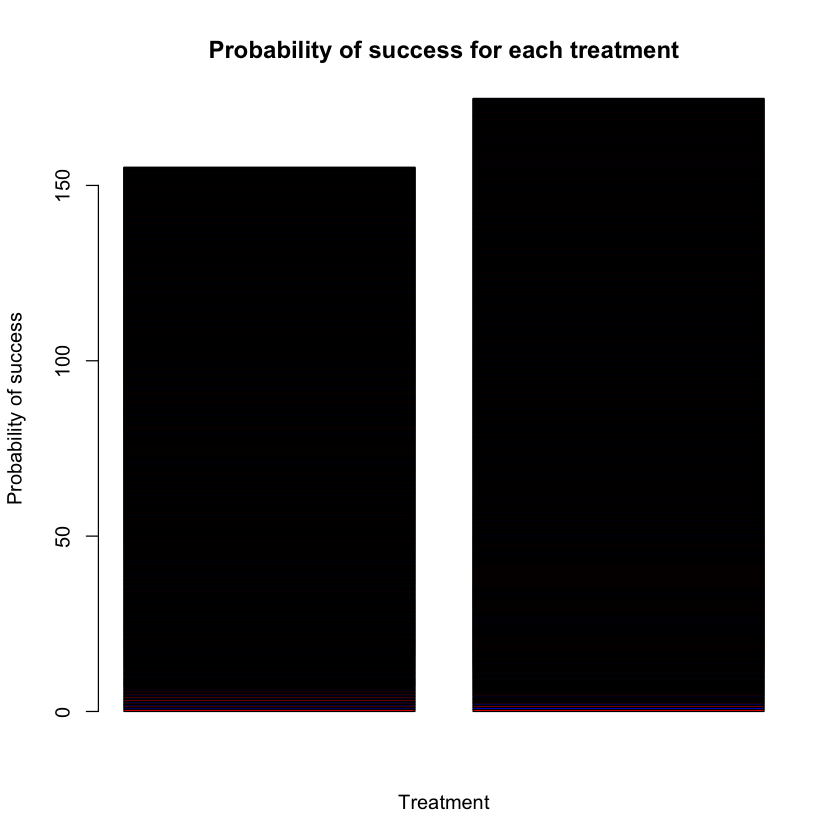

In [21]:
par(bg = "white")
# make a bar plot
barplot(p.record, col = c("red", "blue"), main = "Probability of success for each treatment", xlab = "Treatment", ylab = "Probability of success")

## Assessing Model Fit

We generally want simpler models and has covariates that are important.

To compare GMLs we can use a metric called **residual deviance**:

- we want to determine if the increase in our covariates is worth the decrease in the residuals (because remember more complex models can give lower residuals)

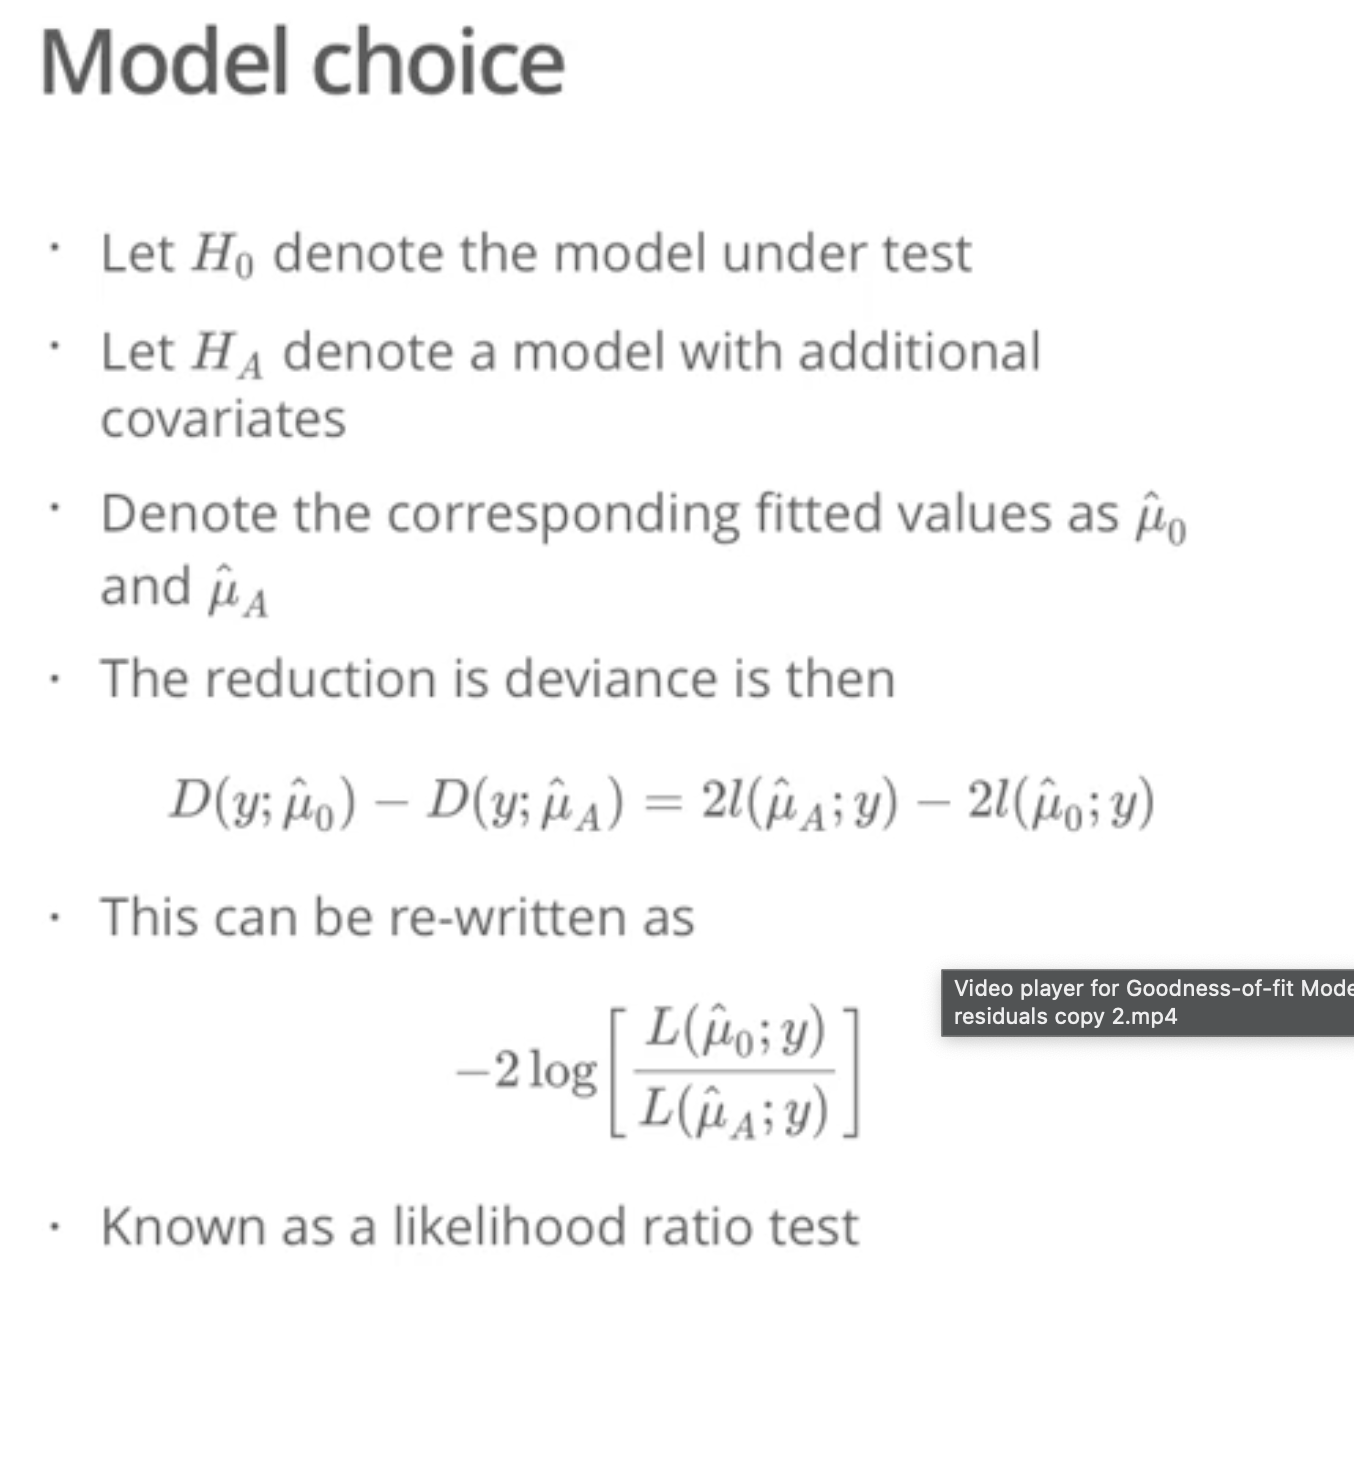

In [35]:
# Read the PNG file in as raw bytes:
png_path <- file.path(getwd(), "image2.png")
raw_data <- readBin(png_path, what = "raw", n = file.info(png_path)$size)

# Now display it:
display_png(raw_data, width = 400, height = 400)


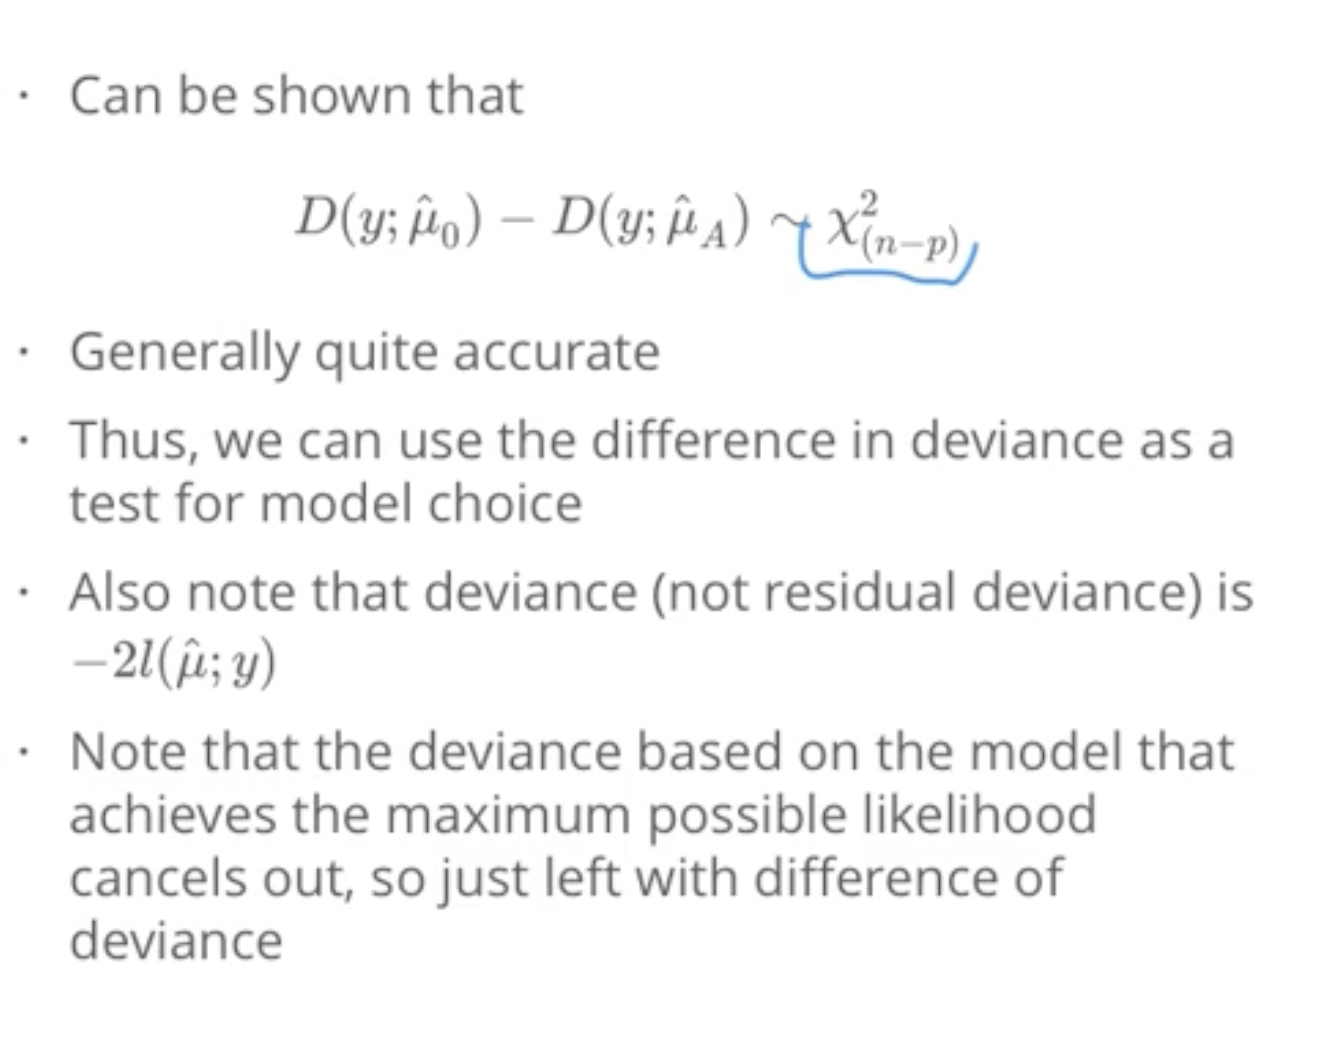

In [36]:
png_path <- file.path(getwd(), "image3.png")
raw_data <- readBin(png_path, what = "raw", n = file.info(png_path)$size)

# Now display it:
display_png(raw_data, width = 400, height = 400)



In [23]:
require(quarto)
quarto::quarto_render("GLMs.html", output_format = "html")

ERROR: Can't determine execution engine for GLMs.html

Stack trace:
    at fileExecutionEngineAndTarget (file:///Applications/quarto/bin/quarto.js:42221:15)
    at eventLoopTick (ext:core/01_core.js:175:7)
    at async render (file:///Applications/quarto/bin/quarto.js:91855:24)
    at async Command.actionHandler (file:///Applications/quarto/bin/quarto.js:92001:32)
    at async Command.execute (file:///Applications/quarto/bin/quarto.js:8253:13)
    at async Command.parseCommand (file:///Applications/quarto/bin/quarto.js:8143:20)
    at async quarto (file:///Applications/quarto/bin/quarto.js:128475:9)
    at async file:///Applications/quarto/bin/quarto.js:128505:9
    at async file:///Applications/quarto/bin/quarto.js:128357:20
    at async mainRunner (file:///Applications/quarto/bin/quarto.js:128359:9)


ERROR: [1m[33mError[39m in `quarto::quarto_render()`:[22m
[1m[22m[31m✖[39m Error running quarto cli.
[1mCaused by error:[22m
[33m![39m System command 'quarto' failed
